# Recursive submodule refinement & Full workflow:
In this notebook we test the recursive submodule refinement and try to run the full workflow including refinement and multistarts. 

TODO: 
- figure out how to optimize/ improve performance -> why is undirected so much slower?
- also test the nonuniform teleportation!

In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
import timeit
import sys
sys.path.append("..") # go to parent folder
import src.map_equation as meq
import src.optimize as opt
from src.utils import generate_sbm, compare_partitions, visual_community_colors

Generating the test networks:

In [2]:
# bigger and less clear community structure
#g_test = .generate_sbm(n=200, c=6, p_in=0.25, p_out=0.05, directed=False, weighted=True)
#g_test_directed = meq.generate_sbm(n=200, c=6, p_in=0.25, p_out=0.05, directed=True, weighted=True)

# simple and small
g_test = generate_sbm(n=100, c=6, p_in=0.25, p_out=0.01, directed=False, weighted=True)
g_test_directed = generate_sbm(n=100, c=6, p_in=0.25, p_out=0.01, directed=True, weighted=True)

### Test submodule refinement
First, let's check if it's generally possible to achieve improvements via the submodule movements from given suboptimal intial partitions:

In [3]:
random_partition = np.random.randint(0, g_test.vcount()-1, g_test.vcount())
print("random partition labels:")
print(np.unique(random_partition))

refined = opt.submodule_movement_optimization(
    g_test,
    communities=random_partition,
    verbose=False
)

print("refined partition labels:")
print(np.unique(refined))

Before = meq.compute_description_length(g_test, random_partition)
After  = meq.compute_description_length(g_test, refined)
print(f"Description length with random partition: {Before:.6f} bits")
print(f"Description length with refined partition: {After:.6f} bits")

random partition labels:
[ 0  1  3  9 10 11 12 15 16 17 19 20 21 23 24 25 26 27 28 29 30 31 32 33
 34 35 37 38 40 41 44 45 47 51 53 54 55 57 58 59 60 61 62 63 64 65 67 68
 69 70 71 73 75 76 77 79 80 81 82 83 85 88 90 95 96 97]
refined partition labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Description length with random partition: 8.453344 bits
Description length with refined partition: 5.219704 bits


In [4]:
trivial_partition = np.arange(g_test.vcount())
print("Trivial partition labels:")
print(np.unique(trivial_partition))

refined = opt.submodule_movement_optimization(
    g_test,
    communities=trivial_partition,
    verbose=False
)

print("refined partition labels:")
print(np.unique(refined))

Before = meq.compute_description_length(g_test, trivial_partition)
After  = meq.compute_description_length(g_test, refined)
print(f"Description length with trivial partition: {Before:.6f} bits")
print(f"Description length with refined partition: {After:.6f} bits")

Trivial partition labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
refined partition labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27]
Description length with trivial partition: 8.486863 bits
Description length with refined partition: 5.516709 bits


This is the one case that used to fail without the adjustment of the node movement optimization.:

In [5]:
coarse_partition = np.zeros(g_test.vcount(), dtype=int)
print("coarse partition labels:")
print(np.unique(coarse_partition))
refined = opt.submodule_movement_optimization(
    g_test,
    communities=coarse_partition,
    verbose=False
)
print("refined partition labels:")
print(np.unique(refined))
Before = meq.compute_description_length(g_test, coarse_partition)
After  = meq.compute_description_length(g_test, refined)
print(f"Description length with coarse partition: {Before:.6f} bits")
print(f"Description length with refined partition: {After:.6f} bits")

coarse partition labels:
[0]
refined partition labels:
[0 1 2 3 4 5 6 7 8 9]
Description length with coarse partition: 6.486863 bits
Description length with refined partition: 4.796846 bits


Test on undirected test network:

In [6]:
g_test = generate_sbm(n=200, c=6, p_in=0.25, p_out=0.01, directed=False, weighted=True)
initial_partition = opt.core_search_algorithm(g_test, verbose=False)
print("\nFinished core algorithm!! \nStarting refinement process...\n")

refined_partition = opt.submodule_movement_optimization(g_test,
                                                    initial_partition,
                                                    verbose=False)

print("Before:", meq.compute_description_length(g_test, initial_partition))
print("After: ", meq.compute_description_length(g_test, refined_partition))


Finished core algorithm!! 
Starting refinement process...

Before: 6.159881391713697
After:  6.159881391713697


Test on directed test network:

In [7]:
initial_partition = opt.core_search_algorithm(g_test_directed, verbose=False)
print("\nFinished core algorithm!! \nStarting refinement process...\n")

refined_partition = opt.submodule_movement_optimization(g_test_directed, initial_partition, verbose=True)

print("Before:", meq.compute_description_length(g_test_directed, initial_partition))
print("After: ", meq.compute_description_length(g_test_directed, refined_partition))


Finished core algorithm!! 
Starting refinement process...

Submodule refinement: Starting with 6 modules, 100 nodes and 505 edges total.
Initial description length: 5.66 bits.

--- Parent module 0 ---
Nodes: 16
Subgraph: 16 nodes, 60 edges

--- Level 0 ------------------------------
    Current Graph: 16 nodes, 60 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 5.799863777690298
Current best description length: 4.535762924068448
Number of nodes moved this iteration: 11
Continuing optimization.
Current best description length: 4.474483183231729
Number of nodes moved this iteration: 4
Continuing optimization.
Current best description length: 4.2281201859460715
Number of nodes moved this iteration: 5
Continuing optimization.
Current best description length: 4.2281201859460715
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 3
Final description length: 4.2281201859460715
    Pha

### Testing the full optimization workflow:
Let's test the full function including core search and refinement, but without multistarts for now

#### Undirected test network:

In [8]:
comms = opt.search_community_partition(g_test, verbose=True)

--- Running community search ---------------------------------------
Input Graph: 200 nodes, 989 edges

--- Run 1/10:  Starting community partition search... -------
Starting from description length L = 9.561199145640478 bits (with trivial parititon)

--- Level 0 ------------------------------
    Current Graph: 200 nodes, 989 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 9.561199145640478
Current best description length: 7.6703497105648495
Number of nodes moved this iteration: 151
Continuing optimization.
Current best description length: 7.2355492919847855
Number of nodes moved this iteration: 53
Continuing optimization.
Current best description length: 7.085863924160385
Number of nodes moved this iteration: 23
Continuing optimization.
Current best description length: 6.9958435732635404
Number of nodes moved this iteration: 13
Continuing optimization.
Current best description length: 6.948434445882769
Number of nod

Comparing to the `igraph` implementation:

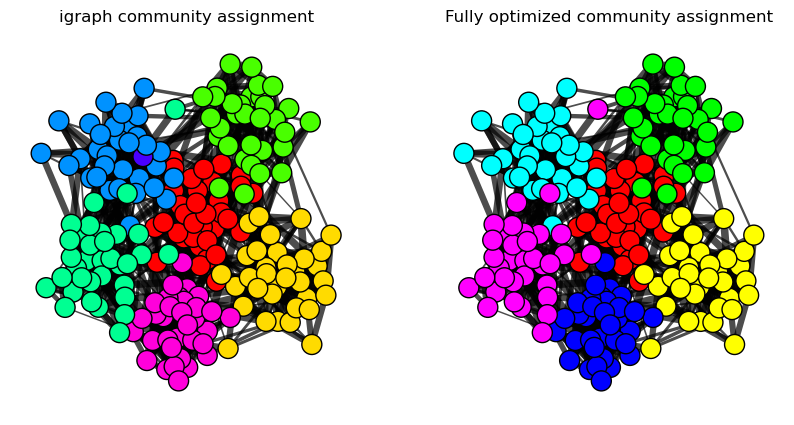

In [9]:
layout = g_test.layout('fr')
comms_ig = g_test.community_infomap(edge_weights=g_test.es['weight'], vertex_weights=None, trials=10)
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **visual_community_colors(g_test, communities=comms_ig.membership, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **visual_community_colors(g_test, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("igraph community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

In [10]:
compare_partitions(comms, comms_ig.membership)
print("custom description length: ", meq.compute_description_length(g_test, comms))
print("igraph description length: ", comms_ig.codelength)
print("igraph description length w custom computation: ", meq.compute_description_length(g_test, comms_ig.membership))

Comparing partitions:
Partition 1: 6 communities
Partition 2: 7 communities
Normalized Mututal Information: 0.9938
Adjusted Rand Index: 0.9941
custom description length:  6.100684982297636
igraph description length:  6.100415670344944
igraph description length w custom computation:  6.100415670344949


and comparing to the ground truth:

In [11]:
ground_truth = g_test.vs["community"]
compare_partitions(comms, ground_truth)
print("custom description length: ", meq.compute_description_length(g_test, comms))
print("ground truth description length: ", meq.compute_description_length(g_test, ground_truth))

Comparing partitions:
Partition 1: 6 communities
Partition 2: 6 communities
Normalized Mututal Information: 0.9875
Adjusted Rand Index: 0.9880
custom description length:  6.100684982297636
ground truth description length:  6.102829892533907


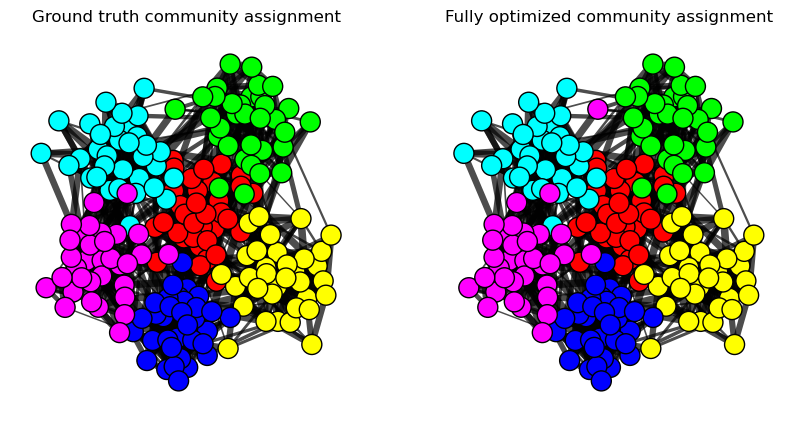

In [12]:
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **visual_community_colors(g_test, communities=ground_truth, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **visual_community_colors(g_test, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("Ground truth community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

#### Directed test network:

In [13]:
comms = opt.search_community_partition(g_test_directed, verbose=True)

--- Running community search ---------------------------------------
Input Graph: 100 nodes, 505 edges

--- Run 1/10:  Starting community partition search... -------
Starting from description length L = 8.36882080562863 bits (with trivial parititon)

--- Level 0 ------------------------------
    Current Graph: 100 nodes, 505 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 8.36882080562863
Current best description length: 6.495140519453173
Number of nodes moved this iteration: 74
Continuing optimization.
Current best description length: 6.3103868322195105
Number of nodes moved this iteration: 14
Continuing optimization.
Current best description length: 6.256443110022353
Number of nodes moved this iteration: 5
Continuing optimization.
Current best description length: 6.256443110022353
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 25
Final description length: 6.2564431100223

Comparing to the `igraph` implementation:

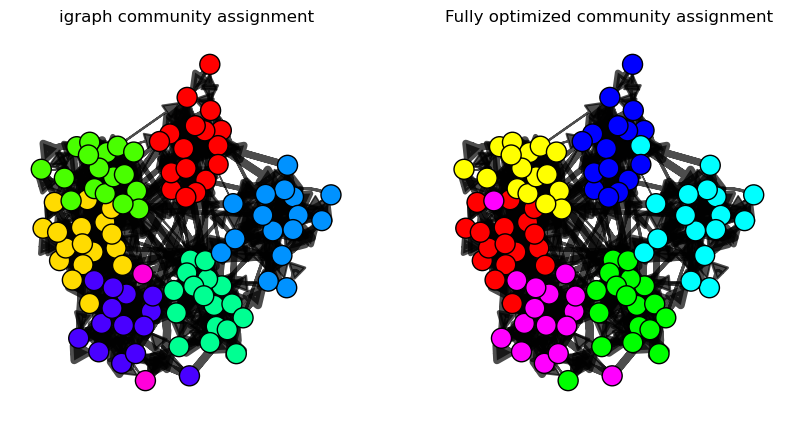

In [14]:
layout = g_test_directed.layout('fr')
comms_ig = g_test_directed.community_infomap(edge_weights=g_test_directed.es['weight'], vertex_weights=None, trials=10)
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout, **visual_community_colors(g_test_directed, communities=comms_ig.membership, skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout, **visual_community_colors(g_test_directed, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("igraph community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

In [15]:
compare_partitions(comms, comms_ig.membership)
print("custom description length: ", meq.compute_description_length(g_test_directed, comms))
print("igraph description length: ", comms_ig.codelength)
print("igraph description length w custom computation: ", meq.compute_description_length(g_test_directed, comms_ig.membership))

Comparing partitions:
Partition 1: 6 communities
Partition 2: 7 communities
Normalized Mututal Information: 0.9339
Adjusted Rand Index: 0.9270
custom description length:  5.602492243921788
igraph description length:  5.21935518236815
igraph description length w custom computation:  5.607459425687586


and to the ground truth:

In [16]:
ground_truth = g_test_directed.vs["community"]
compare_partitions(comms, ground_truth)
print("custom description length: ", meq.compute_description_length(g_test_directed, comms))
print("ground truth description length: ", meq.compute_description_length(g_test_directed, ground_truth))

Comparing partitions:
Partition 1: 6 communities
Partition 2: 6 communities
Normalized Mututal Information: 0.9365
Adjusted Rand Index: 0.9280
custom description length:  5.602492243921788
ground truth description length:  5.607409507380796


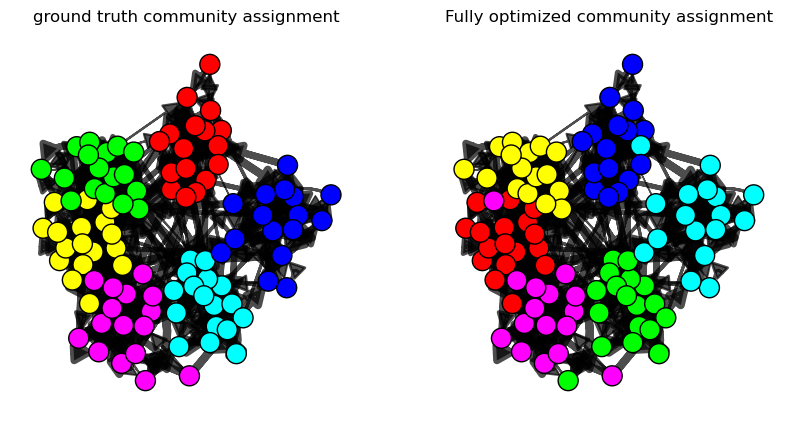

In [17]:
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout, **visual_community_colors(g_test_directed, communities=ground_truth, skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout, **visual_community_colors(g_test_directed, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("ground truth community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

#### Timing the full search algorithm:
This time, including 10 restarts:

In [18]:
%timeit -r50 opt.search_community_partition(g_test, num_restarts=10)

2min 22s ± 1min 8s per loop (mean ± std. dev. of 50 runs, 1 loop each)


In [19]:
%timeit -r50 opt.search_community_partition(g_test_directed, num_restarts=10)

27.8 s ± 3.01 s per loop (mean ± std. dev. of 50 runs, 1 loop each)
